# Cell-Type Classifier

Trains XGBoost, Random Forest, and MLP classifiers on autoencoder features + FR + layer.

**Labels**
- Manual: PC / CF / MF from `*_labels.csv`
- Auto: MLI + GoC from `C4_predicted_cell_type` in `*_table.csv` → class `others`

**CV**: leave-2-sessions-out (14 folds over 28 sessions)

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from pathlib import Path

pkg_parent = Path().resolve().parent.parent
if str(pkg_parent) not in sys.path:
    sys.path.insert(0, str(pkg_parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from sklearn.base import clone
from sklearn.utils.class_weight import compute_class_weight

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    print("xgboost not installed — run: pip install xgboost")
    HAS_XGB = False

from cerebellum_cell_classifier.autoencoders.models import WFConvVAE, ACGConvVAE
from cerebellum_cell_classifier.autoencoders.transforms import normalize_waveforms, normalize_acg3d

print("imports OK")

imports OK


In [2]:
DATASET_DIR    = Path(r"Z:\loco\cell_class\datasets")
CHECKPOINT_DIR = Path("../checkpoints")
N_CHAN_USE     = 8

WF_CKPT  = CHECKPOINT_DIR / "wf"  / "wf_vae_best.pt"
ACG_CKPT = CHECKPOINT_DIR / "acg" / "acg_vae_best.pt"

CLASSES      = ['CF', 'MF', 'PC', 'others']   # fixed order for confusion matrix
CLASS_COLORS = {'PC': '#2196F3', 'CF': '#F44336', 'MF': '#FF9800', 'others': '#4CAF50'}
LAYER_CATS   = ['GCL', 'ML', 'PCL', 'PCL_GCL_interface', 'PCL_ML_interface', 'not_cortex', 'unknown']

NPZ_PATHS = sorted(DATASET_DIR.rglob('*_features.npz'))
print(f"Found {len(NPZ_PATHS)} sessions")

Found 28 sessions


In [3]:
# ── Load trained autoencoders ─────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dev    = torch.device(device)

wf_model = WFConvVAE(n_channels=N_CHAN_USE, n_timepoints=81, latent_dim=10).to(dev)
wf_model.load_state_dict(torch.load(WF_CKPT, map_location=dev))
wf_model.eval()

acg_model = ACGConvVAE(latent_dim=10).to(dev)
acg_model.load_state_dict(torch.load(ACG_CKPT, map_location=dev))
acg_model.eval()

print(f"Models loaded on {device}")

Models loaded on cuda


C:\Users\lidor\AppData\Local\Temp\ipykernel_218320\1081921677.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wf_model.load_state_dict(torch.load(WF_CKPT, map_location=d

In [4]:
@torch.no_grad()
def encode_with_ae(wf_raw, acg_raw, n_chan_use=N_CHAN_USE):
    """Return (wf_z, acg_z) each (N, 10)."""
    wf_n  = normalize_waveforms(wf_raw)[:, :n_chan_use, :][:, np.newaxis]
    wf_t  = torch.from_numpy(wf_n).to(dev)
    wf_z  = wf_model.encode(wf_t).cpu().numpy()

    acg_n = normalize_acg3d(acg_raw)
    acg_t = torch.from_numpy(acg_n).to(dev)
    acg_z = acg_model.encode(acg_t).cpu().numpy()
    return wf_z, acg_z


def assign_class(label, c4):
    if label in ('PC', 'CF', 'MF'):
        return label
    if c4 in ('MLI', 'GoC'):
        return 'others'
    return 'unknown'


def load_session(npz_path):
    npz_path  = Path(npz_path)
    stem      = npz_path.stem.replace('_features', '')
    lbl_path  = npz_path.parent / f"{stem}_labels.csv"
    tbl_path  = npz_path.parent / f"{stem}_table.csv"

    npz      = np.load(npz_path, allow_pickle=True)
    unit_ids = npz['unit_ids']
    wf_raw   = npz['mean_waveforms'].astype(np.float32)
    acg_raw  = npz['acg_3d'].astype(np.float32)
    session  = str(npz['session_name'])

    df = pd.DataFrame({'unit_id': unit_ids, 'session': session})

    # manual labels
    if lbl_path.exists():
        lbl = pd.read_csv(lbl_path)[['unit_id', 'label']]
        df  = df.merge(lbl, on='unit_id', how='left')
        df['label'] = df['label'].fillna('unknown')
    else:
        df['label'] = 'unknown'

    # table: FR, layer, C4
    if tbl_path.exists():
        tbl_cols = ['unit_id', 'mean_fr_hz', 'neuron_layer', 'C4_predicted_cell_type']
        tbl = pd.read_csv(tbl_path)[[c for c in tbl_cols if c in pd.read_csv(tbl_path, nrows=0).columns]]
        df  = df.merge(tbl, on='unit_id', how='left')
    else:
        df['mean_fr_hz'] = np.nan
        df['neuron_layer'] = 'unknown'
        df['C4_predicted_cell_type'] = np.nan

    df['mean_fr_hz']           = df.get('mean_fr_hz', pd.Series(np.nan, index=df.index)).fillna(0)
    df['neuron_layer']         = df.get('neuron_layer', pd.Series('unknown', index=df.index)).fillna('unknown')
    df['C4_predicted_cell_type'] = df.get('C4_predicted_cell_type', pd.Series('', index=df.index)).fillna('')

    df['class'] = df.apply(lambda r: assign_class(r['label'], r['C4_predicted_cell_type']), axis=1)

    # AE features
    wf_z, acg_z = encode_with_ae(wf_raw, acg_raw)
    for i in range(10):
        df[f'wf_{i}']  = wf_z[:, i]
        df[f'acg_{i}'] = acg_z[:, i]

    return df

print("functions defined")

functions defined


In [5]:
# ── Build master DataFrame ────────────────────────────────────────────────────
all_dfs = []
for p in NPZ_PATHS:
    try:
        all_dfs.append(load_session(p))
        print(f"  {Path(p).parent.name:20s}  loaded")
    except Exception as e:
        print(f"  {Path(p).parent.name:20s}  FAILED: {e}")

df = pd.concat(all_dfs, ignore_index=True)

# one-hot encode layer (consistent columns across all sessions)
for cat in LAYER_CATS:
    df[f'layer_{cat}'] = (df['neuron_layer'] == cat).astype(np.float32)

WF_COLS      = [f'wf_{i}'      for i in range(10)]
ACG_COLS     = [f'acg_{i}'     for i in range(10)]
LAYER_COLS   = [f'layer_{c}'   for c in LAYER_CATS]
FEATURE_COLS = WF_COLS + ACG_COLS + ['mean_fr_hz'] + LAYER_COLS

df_labeled = df[df['class'] != 'unknown'].copy()

print(f"\nTotal units  : {len(df)}")
print(f"Labeled units: {len(df_labeled)}")
print()
print(df_labeled['class'].value_counts())

  AA11_01               loaded
  AA11_02               loaded
  AA11_08               loaded
  AA11_10               loaded
  AA23_01               loaded
  AA23_02               loaded
  AA23_03               loaded
  AA23_05               loaded
  AA23_07               loaded
  AA23_11               loaded
  CB01_04               loaded
  CB01_05               loaded
  CB01_06               loaded
  CB01_08               loaded
  CB01_09               loaded
  CB01_11               loaded
  CB01_12               loaded
  CB01_13               loaded
  CB01_14               loaded
  XG009                 loaded
  XG021                 loaded
  XG031_01              loaded
  XG031_02              loaded
  XG032_01              loaded
  XG032_02              loaded
  XG037                 loaded
  XG046                 loaded
  XG048                 loaded

Total units  : 5744
Labeled units: 2321

class
CF        1153
others     596
MF         432
PC         140
Name: count, dtype: int6

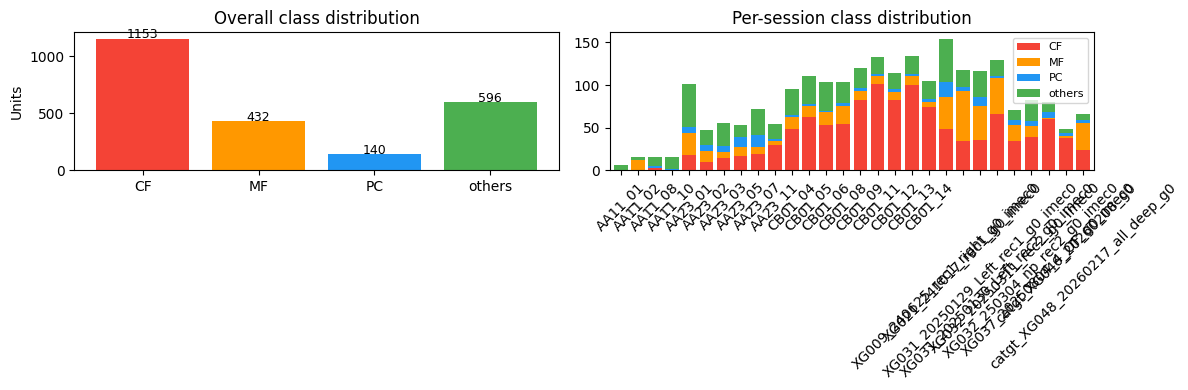

In [6]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# overall
counts = df_labeled['class'].value_counts().reindex(CLASSES, fill_value=0)
axes[0].bar(counts.index, counts.values,
            color=[CLASS_COLORS[c] for c in counts.index])
axes[0].set_title('Overall class distribution')
axes[0].set_ylabel('Units')
for ax, val in zip(axes[0].patches, counts.values):
    axes[0].text(ax.get_x() + ax.get_width()/2, ax.get_height() + 5,
                 str(val), ha='center', fontsize=9)

# per session
sess_counts = (df_labeled.groupby(['session', 'class'])
               .size().unstack(fill_value=0)
               .reindex(columns=CLASSES, fill_value=0))
sess_counts.plot(kind='bar', ax=axes[1],
                 color=[CLASS_COLORS[c] for c in CLASSES],
                 stacked=True, width=0.8)
axes[1].set_title('Per-session class distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

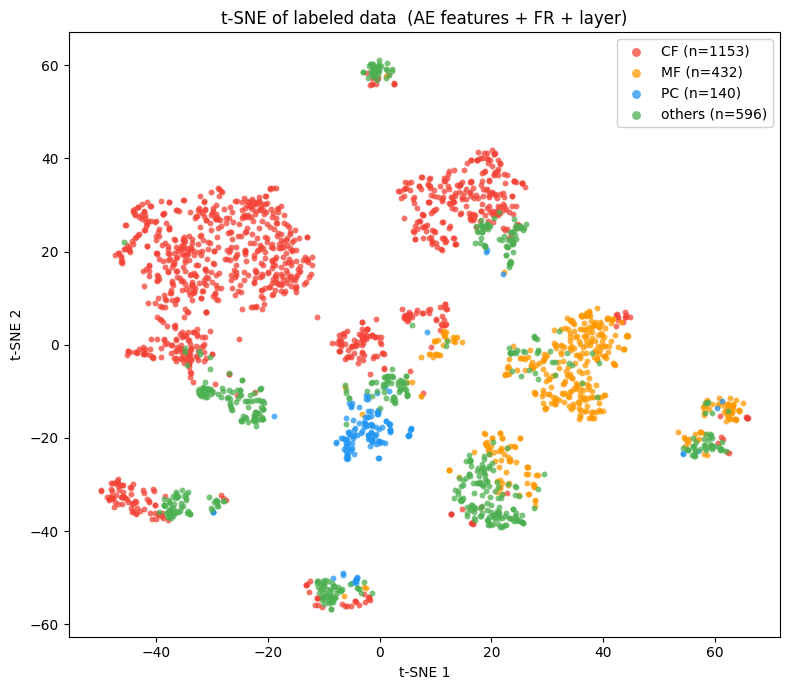

In [7]:
# ── t-SNE of labeled data ─────────────────────────────────────────────────────
X_all = df_labeled[FEATURE_COLS].values.astype(np.float32)
X_all = np.nan_to_num(X_all)

scaler_viz = StandardScaler()
X_scaled   = scaler_viz.fit_transform(X_all)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
Z    = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 7))
for cls in CLASSES:
    mask = df_labeled['class'].values == cls
    if mask.sum() == 0:
        continue
    ax.scatter(Z[mask, 0], Z[mask, 1],
               c=CLASS_COLORS[cls], label=f"{cls} (n={mask.sum()})",
               s=18, alpha=0.75, linewidths=0)

ax.set_title('t-SNE of labeled data  (AE features + FR + layer)', fontsize=12)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(framealpha=0.9, markerscale=1.5)
plt.tight_layout()
plt.show()

## Classifiers — Leave-2-Sessions-Out CV

In [8]:
# ── Build folds ───────────────────────────────────────────────────────────────
sessions = sorted(df_labeled['session'].unique())
folds    = [(sessions[i], sessions[i+1]) for i in range(0, len(sessions)-1, 2)]
if len(sessions) % 2 == 1:                      # odd number: last fold has 1
    folds.append((sessions[-1],))
print(f"{len(folds)} folds over {len(sessions)} sessions")

# ── Define classifiers ────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(CLASSES)

classifiers = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'MLP':           MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),
}
if HAS_XGB:
    classifiers['XGBoost'] = xgb.XGBClassifier(
        n_estimators=300, eval_metric='mlogloss', random_state=42,
        n_jobs=-1, verbosity=0)

cv_results = {name: {'acc': [], 'f1': [], 'true': [], 'pred': []}
              for name in classifiers}

# ── CV loop ───────────────────────────────────────────────────────────────────
for fold_idx, val_sess in enumerate(folds):
    val_mask   = df_labeled['session'].isin(val_sess)
    train_mask = ~val_mask

    X_tr = df_labeled.loc[train_mask, FEATURE_COLS].values.astype(np.float32)
    y_tr = df_labeled.loc[train_mask, 'class'].values
    X_va = df_labeled.loc[val_mask,   FEATURE_COLS].values.astype(np.float32)
    y_va = df_labeled.loc[val_mask,   'class'].values

    if len(X_va) == 0:
        continue

    scaler    = StandardScaler()
    X_tr_s    = np.nan_to_num(scaler.fit_transform(X_tr))
    X_va_s    = np.nan_to_num(scaler.transform(X_va))

    # sample weights for imbalance
    cw      = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict = dict(zip(np.unique(y_tr), cw))
    sw      = np.array([cw_dict[y] for y in y_tr])

    y_tr_enc = le.transform(y_tr)
    y_va_enc = le.transform(y_va)

    for name, clf in classifiers.items():
        clf_c = clone(clf)
        if name == 'XGBoost':
            clf_c.fit(X_tr_s, y_tr_enc, sample_weight=sw)
            y_pred = le.inverse_transform(clf_c.predict(X_va_s))
        else:
            clf_c.fit(X_tr_s, y_tr)
            y_pred = clf_c.predict(X_va_s)

        acc = accuracy_score(y_va, y_pred)
        f1  = f1_score(y_va, y_pred, average='weighted',
                       labels=CLASSES, zero_division=0)
        cv_results[name]['acc'].append(acc)
        cv_results[name]['f1'].append(f1)
        cv_results[name]['true'].extend(y_va.tolist())
        cv_results[name]['pred'].extend(y_pred.tolist())

    n_tr = train_mask.sum(); n_va = val_mask.sum()
    print(f"Fold {fold_idx+1:2d}/{len(folds)}  val={list(val_sess)}  "
          f"n_train={n_tr}  n_val={n_va}")

print("\n── CV complete ──")
for name, res in cv_results.items():
    print(f"  {name:15s}  acc={np.mean(res['acc']):.3f}±{np.std(res['acc']):.3f}  "
          f"F1={np.mean(res['f1']):.3f}±{np.std(res['f1']):.3f}")

14 folds over 28 sessions
Fold  1/14  val=['AA11_01', 'AA11_02']  n_train=2299  n_val=22
Fold  2/14  val=['AA11_08', 'AA11_10']  n_train=2289  n_val=32
Fold  3/14  val=['AA23_01', 'AA23_02']  n_train=2173  n_val=148
Fold  4/14  val=['AA23_03', 'AA23_05']  n_train=2212  n_val=109
Fold  5/14  val=['AA23_07', 'AA23_11']  n_train=2195  n_val=126
Fold  6/14  val=['CB01_04', 'CB01_05']  n_train=2116  n_val=205
Fold  7/14  val=['CB01_06', 'CB01_08']  n_train=2114  n_val=207
Fold  8/14  val=['CB01_09', 'CB01_11']  n_train=2068  n_val=253
Fold  9/14  val=['CB01_12', 'CB01_13']  n_train=2073  n_val=248
Fold 10/14  val=['CB01_14', 'XG009_240625_rec1_right_g0_imec0']  n_train=2062  n_val=259
Fold 11/14  val=['XG021_241017_rec1_g0_imec0', 'XG031_20250129_Left_rec1_g0_imec0']  n_train=2086  n_val=235
Fold 12/14  val=['XG031_20250130_Left_rec2_g0_imec0', 'XG032_20250311_rec2_g0_imec0']  n_train=2121  n_val=200
Fold 13/14  val=['XG032_250304_np_rec2_g0_imec0', 'XG037_20250804_4_OF_g0_imec0']  n_train=

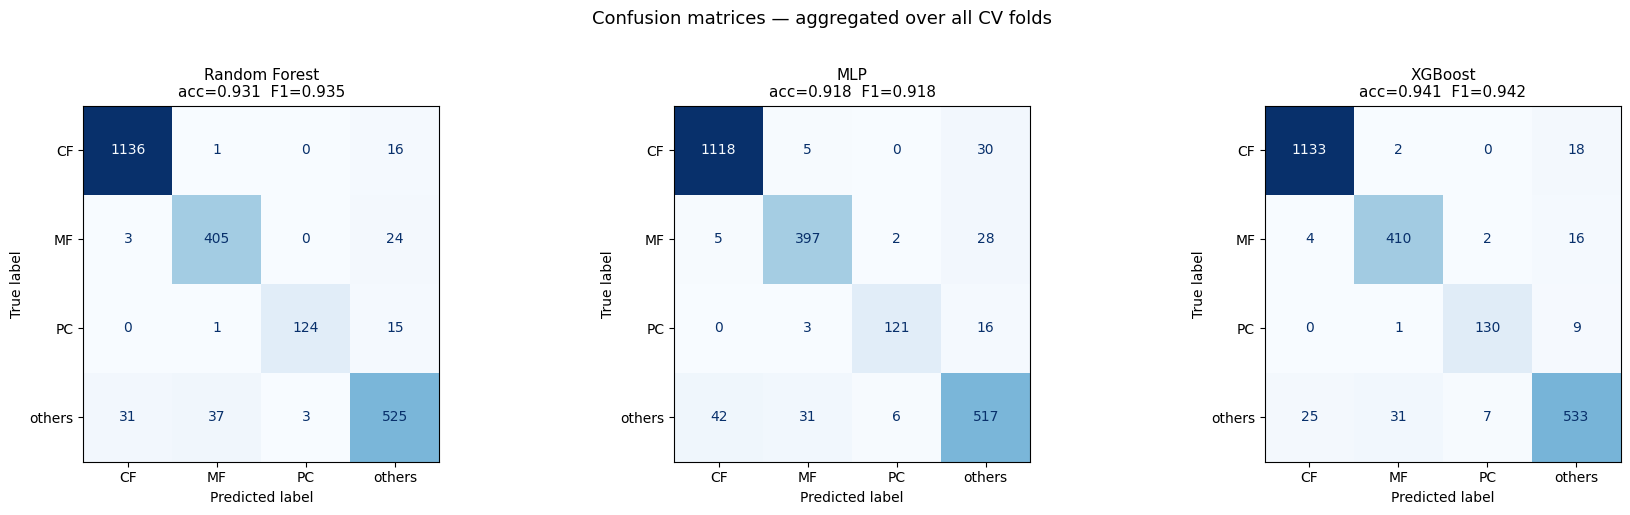

In [9]:
# ── Confusion matrices (aggregated across all folds) ─────────────────────────
n_clf = len(cv_results)
fig, axes = plt.subplots(1, n_clf, figsize=(6 * n_clf, 5))
if n_clf == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, cv_results.items()):
    cm = confusion_matrix(res['true'], res['pred'], labels=CLASSES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = np.mean(res['acc'])
    f1  = np.mean(res['f1'])
    ax.set_title(f"{name}\nacc={acc:.3f}  F1={f1:.3f}", fontsize=11)

plt.suptitle('Confusion matrices — aggregated over all CV folds', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

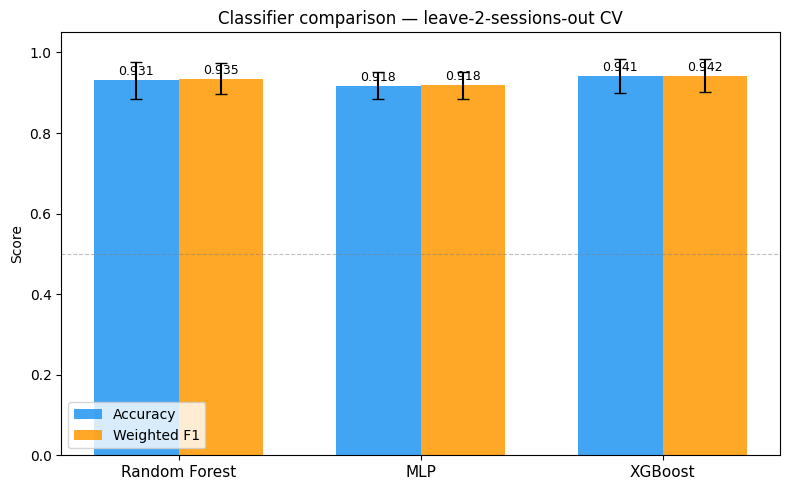

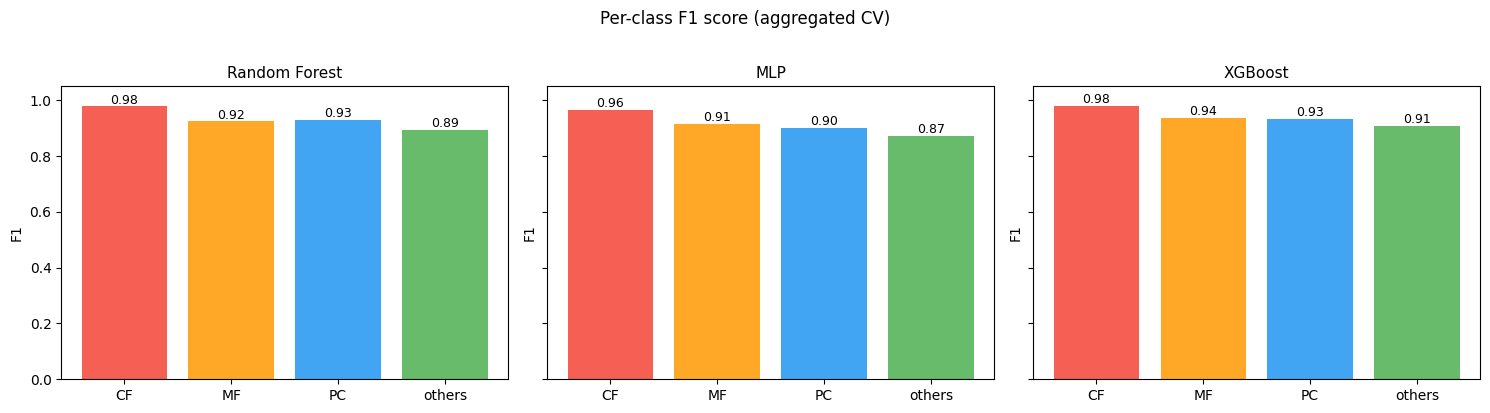

In [10]:
# ── Accuracy + F1 comparison across classifiers ───────────────────────────────
names   = list(cv_results.keys())
accs    = [np.mean(cv_results[n]['acc']) for n in names]
acc_std = [np.std(cv_results[n]['acc'])  for n in names]
f1s     = [np.mean(cv_results[n]['f1'])  for n in names]
f1_std  = [np.std(cv_results[n]['f1'])   for n in names]

x   = np.arange(len(names))
w   = 0.35
fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - w/2, accs, w, yerr=acc_std, capsize=4,
               label='Accuracy', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + w/2, f1s,  w, yerr=f1_std,  capsize=4,
               label='Weighted F1', color='#FF9800', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Classifier comparison — leave-2-sessions-out CV', fontsize=12)
ax.legend()
ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

# ── Per-class F1 breakdown ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_clf, figsize=(5 * n_clf, 4), sharey=True)
if n_clf == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, cv_results.items()):
    f1_per_class = f1_score(res['true'], res['pred'],
                            labels=CLASSES, average=None, zero_division=0)
    ax.bar(CLASSES, f1_per_class,
           color=[CLASS_COLORS[c] for c in CLASSES], alpha=0.85)
    for i, v in enumerate(f1_per_class):
        ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
    ax.set_title(name, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1')

plt.suptitle('Per-class F1 score (aggregated CV)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()